In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

dataset_path = "/content/drive/MyDrive/Chickpeas Classification/Aug+Real"
classes = ["fresh", "infected"]

# Dictionary to store counts
image_counts = {}

for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    image_counts[cls] = count

# Print counts
for cls, count in image_counts.items():
    print(f"{cls} → {count} images")

print("\n✅ Total Images:", sum(image_counts.values()))
import os

dataset_path = "/content/drive/MyDrive/Chickpeas Classification/Aug+Real"
classes = ["fresh", "infected"]

# Dictionary to store counts
image_counts = {}

for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    image_counts[cls] = count

# Print counts
for cls, count in image_counts.items():
    print(f"{cls} → {count} images")

print("\n✅ Total Images:", sum(image_counts.values()))


fresh → 5000 images
infected → 5000 images

✅ Total Images: 10000
fresh → 5000 images
infected → 5000 images

✅ Total Images: 10000


In [3]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split


# Paths
Final_data_path = "/content/drive/MyDrive/Chickpeas Classification/Aug+Real"
output_dir = "/content/Final_split"

# Classes (from your final dataset)
classes = ["fresh", "infected"] # Removed "Unknown"

# Clean old split if exists
shutil.rmtree(output_dir, ignore_errors=True)

# Create output folders
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

# Split ratio
train_ratio = 0.8
val_ratio = 0.10
test_ratio = 0.10

random.seed(42)  # reproducibility

for cls in classes:
    class_dir = os.path.join(Final_data_path, cls)

    if not os.path.exists(class_dir):
        print(f"⚠️ Skipping {cls} because folder not found")
        continue

    all_files = [f for f in os.listdir(class_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # First split: train vs temp (val+test)
    train_files, temp_files = train_test_split(
        all_files, test_size=1-train_ratio, random_state=42
    )

    # Second split: val vs test
    val_files, test_files = train_test_split(
        temp_files, test_size=test_ratio/(val_ratio+test_ratio), random_state=42
    )

    # Copy files to respective directories
    for f in train_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "train", cls, f)
        shutil.copy2(src, dst)

    for f in val_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "val", cls, f)
        shutil.copy2(src, dst)

    for f in test_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "test", cls, f)
        shutil.copy2(src, dst)

    print(f"✅ {cls}: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test")

print("\n🎯 Dataset split completed!")

✅ fresh: 4000 train, 500 val, 500 test
✅ infected: 4000 train, 500 val, 500 test

🎯 Dataset split completed!


Classes: ['fresh', 'infected']
Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 25,819,073 (98.49 MB)

 Trainable params: 25,817,857 (98.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 138s 505ms/step - accuracy: 0.9666 - loss: 0.1209 - val_accuracy: 0.5000 - val_loss: 1.9445
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 114s 454ms/step - accuracy: 0.9925 - loss: 0.0407 - val_accuracy: 0.9750 - val_loss: 0.0976
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 118s 469ms/step - accuracy: 0.9942 - loss: 0.0262 - val_accuracy: 0.9940 - val_loss: 0.0208
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 436ms/step - accuracy: 0.9967 - loss: 0.0166 - val_accuracy: 0.9920 - val_loss: 0.0224
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 436ms/step - accuracy: 0.9973 - loss: 0.0152 - val_accuracy: 0.9960 - val_loss: 0.0107
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 447ms/step - accuracy: 0.9958 - loss: 0.0188 - val_accuracy: 0.9970 - val_loss: 0.0127
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 116s 461ms/step - accuracy: 0.9990 - loss: 0.0093 - val_accuracy: 0.9970 - val_loss: 0.0104
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 111s 442ms/step - accuracy: 0.9979 -

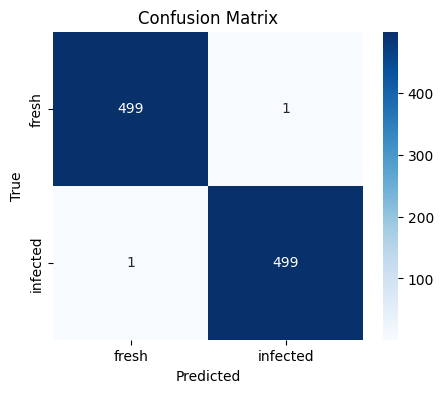


Classification Report:

              precision    recall  f1-score   support

       fresh     0.9980    0.9980    0.9980       500
    infected     0.9980    0.9980    0.9980       500

    accuracy                         0.9980      1000
   macro avg     0.9980    0.9980    0.9980      1000
weighted avg     0.9980    0.9980    0.9980      1000


🔹 Macro Average Accuracy (Precision Avg): 0.9980
🔹 Overall Test Accuracy: 0.9980


In [4]:
# --------------------------
# CNN (Fresh vs Infected) - Sigmoid Version
# --------------------------
import os
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --------------------------
# Paths & parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (224, 224)
batch_size = 32
epochs = 10

# Class names
class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators (CHANGED)
# --------------------------
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",   # ✅ changed
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",   # ✅ changed
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",   # ✅ changed
    shuffle=False
)

# --------------------------
# CNN Model (CHANGED FINAL LAYER)
# --------------------------
model_cnn = Sequential([
    Conv2D(32, (3,3), padding="same", input_shape=(224,224,3)),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.5),

    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.3),

    Dense(1, activation='sigmoid')   # ✅ changed
])

# --------------------------
# Compile (CHANGED)
# --------------------------
model_cnn.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',   # ✅ changed
    metrics=['accuracy']
)

model_cnn.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_cnn_model.keras"
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train Model
# --------------------------
history = model_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Evaluation (CHANGED PREDICTION)
# --------------------------
y_pred = model_cnn.predict(test_gen)

# ✅ sigmoid threshold
y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)

y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# --------------------------
# Macro Accuracy & Overall Accuracy
# --------------------------
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
print(f"\n🔹 Macro Average Accuracy (Precision Avg): {macro_accuracy:.4f}")

overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 Overall Test Accuracy: {overall_acc:.4f}")

Classes: ['fresh', 'infected']
Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,334,594 (27.98 MB)

 Trainable params: 663,490 (2.53 MB)

 Non-trainable params: 6,671,104 (25.45 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 240s 816ms/step - accuracy: 0.7959 - loss: 1.5162 - val_accuracy: 0.9950 - val_loss: 1.0841
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 161s 644ms/step - accuracy: 0.9616 - loss: 1.0671 - val_accuracy: 0.9980 - val_loss: 0.9044
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 155s 618ms/step - accuracy: 0.9822 - loss: 0.9059 - val_accuracy: 1.0000 - val_loss: 0.8049
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 154s 616ms/step - accuracy: 0.9916 - loss: 0.8027 - val_accuracy: 1.0000 - val_loss: 0.7369
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 152s 604ms/step - accuracy: 0.9934 - loss: 0.7378 - val_accuracy: 1.0000 - val_loss: 0.6864
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 219s 674ms/step - accuracy: 0.9952 - loss: 0.6872 - val_accuracy: 1.0000 - val_loss: 0.6451
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 151s 604ms/step - accuracy: 0.9950 - loss: 0.6468 - val_accuracy: 1.0000 - val_loss: 0.6083
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 159s 633ms/step - accuracy: 0.9976 -

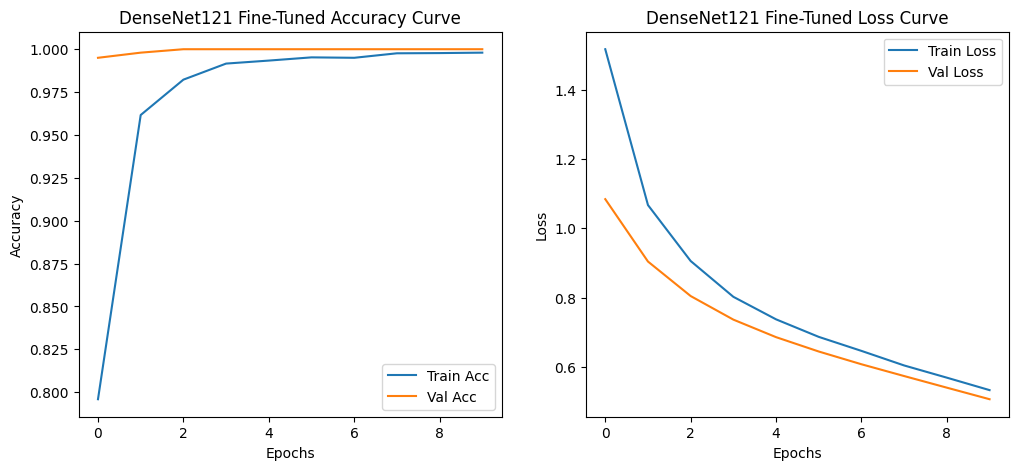

32/32 ━━━━━━━━━━━━━━━━━━━━ 39s 840ms/step


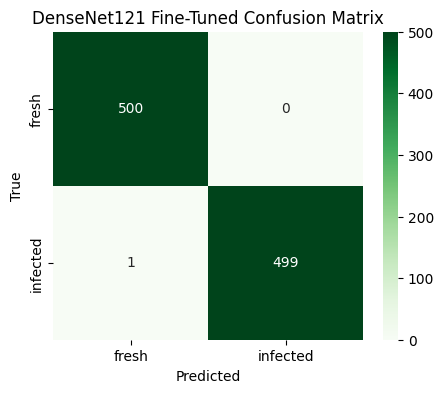


DenseNet121 Fine-Tuned Classification Report:

              precision    recall  f1-score   support

       fresh     0.9980    1.0000    0.9990       500
    infected     1.0000    0.9980    0.9990       500

    accuracy                         0.9990      1000
   macro avg     0.9990    0.9990    0.9990      1000
weighted avg     0.9990    0.9990    0.9990      1000

🔹 DenseNet121 Macro Average Accuracy: 0.9990
🔹 DenseNet121 Overall Test Accuracy: 0.9990


In [1]:
# --------------------------
# Refined DenseNet121 (Target Accuracy ~95–98%)
# --------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --------------------------
# Paths & Parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (128, 128)  # smaller image size to reduce overfitting
batch_size = 32
epochs = 10

class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators (Stronger Augmentation)
# --------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

# --------------------------
# Base DenseNet121 Model
# --------------------------
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))

# Freeze most layers (only fine-tune last 20 layers)
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Custom Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.002))(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.6)(x)
x = Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.002))(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.4)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

model_densenet = Model(inputs=base_model.input, outputs=predictions)

# --------------------------
# Compile Model
# --------------------------
model_densenet.compile(
    optimizer=Adam(learning_rate=5e-5),  # smaller LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_densenet.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_refined_densenet121_v2.keras"
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train Model
# --------------------------
history = model_densenet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Plot Accuracy & Loss
# --------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("DenseNet121 Fine-Tuned Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("DenseNet121 Fine-Tuned Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --------------------------
# Evaluation on Test Data
# --------------------------
y_pred = model_densenet.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DenseNet121 Fine-Tuned Confusion Matrix")
plt.show()

report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nDenseNet121 Fine-Tuned Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# --------------------------
# Macro Accuracy & Overall Accuracy
# --------------------------
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 DenseNet121 Macro Average Accuracy: {macro_accuracy:.4f}")
print(f"🔹 DenseNet121 Overall Test Accuracy: {overall_acc:.4f}")


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# --------------------------
# Feature Extraction with DenseNet121
# --------------------------
# Assuming train_gen is the full dataset generator (images + labels)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128,128,3)) # Changed input_shape to (128, 128, 3)
x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Function to extract features
def extract_features(generator):
    features, labels = [], []
    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat = feature_extractor.predict(x_batch, verbose=0)
        features.append(feat)
        labels.append(y_batch)
    features = np.vstack(features)
    labels = np.hstack(labels)
    return features, labels

print("Extracting features from full dataset...")
X, y = extract_features(train_gen)

# --------------------------
# 10-Fold Cross Validation
# --------------------------
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

precisions, recalls, f1s, accuracies = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_fold, y_train_fold)
    y_pred_fold = clf.predict(X_val_fold)

    precision = precision_score(y_val_fold, y_pred_fold, average='macro')
    recall = recall_score(y_val_fold, y_pred_fold, average='macro')
    f1 = f1_score(y_val_fold, y_pred_fold, average='macro')
    acc = accuracy_score(y_val_fold, y_pred_fold)

    # Print fold metrics
    print(f"Fold {fold}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, Accuracy={acc:.4f}")

    # Save for overall average
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)
    accuracies.append(acc)

# --------------------------
# Average metrics across folds
# --------------------------
print("\n===== 10-Fold CV Average Metrics =====")
print(f"Macro Precision: {np.mean(precisions):.4f}")
print(f"Macro Recall:    {np.mean(recalls):.4f}")
print(f"Macro F1-score:  {np.mean(f1s):.4f}")
print(f"Accuracy:        {np.mean(accuracies):.4f}")

Extracting features from full dataset...
Fold 1: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 2: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 3: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 4: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 5: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 6: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 7: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 8: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 9: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 10: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988

===== 10-Fold CV Average Metrics =====
Macro Precision: 0.9990
Macro Recall:    0.9990
Macro F1-score:  0.9990
Accuracy:        0.9990


In [3]:
# =========================================
# DenseNet121 Feature Extraction + ML Classifiers
# 10-Fold Cross Validation + 95% CI
# =========================================

import os
import numpy as np
import scipy.stats as stats

import tensorflow as tf

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import StratifiedKFold

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================
# 🔹 PATHS & PARAMETERS
# =========================================
output_dir = "/content/Final_split"

img_size = (128, 128)

batch_size = 32

# =========================================
# 🔹 DATA GENERATOR
# =========================================
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())

print("Classes:", class_names)

# =========================================
# 🔹 DENSENET121 FEATURE EXTRACTOR
# =========================================
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size[0], img_size[1], 3)
)

# Fine-tune last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

# Custom head
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    kernel_regularizer=tf.keras.regularizers.l2(0.002)
)(x)

x = BatchNormalization()(x)

x = tf.keras.layers.Activation("relu")(x)

x = Dropout(0.6)(x)

x = Dense(
    128,
    kernel_regularizer=tf.keras.regularizers.l2(0.002)
)(x)

x = BatchNormalization()(x)

x = tf.keras.layers.Activation("relu")(x)

x = Dropout(0.4)(x)

# Final Dense Layer
feature_output = Dense(
    64,
    activation='relu'
)(x)

# Feature extractor model
feature_extractor = Model(
    inputs=base_model.input,
    outputs=feature_output
)

print("\nExtracting features using DenseNet121...")

# =========================================
# 🔹 FEATURE EXTRACTION FUNCTION
# =========================================
def extract_features(generator):

    features = []
    labels = []

    for i in range(len(generator)):

        x_batch, y_batch = generator[i]

        feat = feature_extractor.predict(
            x_batch,
            verbose=0
        )

        features.append(feat)

        labels.append(y_batch)

    features = np.vstack(features)

    labels = np.hstack(labels)

    return features, labels

# =========================================
# 🔹 EXTRACT FEATURES
# =========================================
X, y = extract_features(train_gen)

print("Feature Shape:", X.shape)

# =========================================
# 🔹 FEATURE SCALING
# =========================================
scaler = StandardScaler()

X = scaler.fit_transform(X)

# =========================================
# 🔹 CLASSIFIERS
# =========================================
classifiers = {

    "SVM": SVC(
        kernel='rbf',
        probability=True
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "RF": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "DT": DecisionTreeClassifier(
        random_state=42
    ),

    "GB": GradientBoostingClassifier(
        random_state=42
    )
}

# =========================================
# 🔹 10-FOLD SETUP
# =========================================
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

results = {}

# =========================================
# 🔹 TRAIN + EVALUATE
# =========================================
for name, clf in classifiers.items():

    print(f"\n===== {name} =====")

    accs = []
    precs = []
    recs = []
    f1s = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

        X_train, X_val = X[train_idx], X[val_idx]

        y_train, y_val = y[train_idx], y[val_idx]

        # Train classifier
        clf.fit(X_train, y_train)

        # Predict
        y_pred = clf.predict(X_val)

        # Metrics
        acc = accuracy_score(
            y_val,
            y_pred
        )

        prec = precision_score(
            y_val,
            y_pred,
            average='macro'
        )

        rec = recall_score(
            y_val,
            y_pred,
            average='macro'
        )

        f1 = f1_score(
            y_val,
            y_pred,
            average='macro'
        )

        accs.append(acc)
        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)

        print(
            f"Fold {fold}: "
            f"Acc={acc:.6f}, "
            f"F1={f1:.6f}"
        )

    results[name] = {

        "acc": accs,

        "prec": precs,

        "rec": recs,

        "f1": f1s
    }

# =========================================
# 🔹 CONFIDENCE INTERVAL FUNCTION
# =========================================
def compute_ci(data):

    mean = np.mean(data)

    std = np.std(data)

    n = len(data)

    ci = stats.t.interval(
        0.95,
        df=n-1,
        loc=mean,
        scale=std/np.sqrt(n)
    )

    return mean, ci

# =========================================
# 🔹 FINAL RESULTS (95% CI)
# =========================================
print("\n===== FINAL RESULTS (95% CI) =====")

for name in classifiers.keys():

    print(f"\n🔹 {name}")

    acc_mean, acc_ci = compute_ci(
        results[name]["acc"]
    )

    f1_mean, f1_ci = compute_ci(
        results[name]["f1"]
    )

    prec_mean, prec_ci = compute_ci(
        results[name]["prec"]
    )

    rec_mean, rec_ci = compute_ci(
        results[name]["rec"]
    )

    print(
        f"Accuracy : "
        f"{acc_mean:.6f} "
        f"({acc_ci[0]:.6f}, {acc_ci[1]:.6f})"
    )

    print(
        f"F1-score : "
        f"{f1_mean:.6f} "
        f"({f1_ci[0]:.6f}, {f1_ci[1]:.6f})"
    )

    print(
        f"Precision: "
        f"{prec_mean:.6f} "
        f"({prec_ci[0]:.6f}, {prec_ci[1]:.6f})"
    )

    print(
        f"Recall   : "
        f"{rec_mean:.6f} "
        f"({rec_ci[0]:.6f}, {rec_ci[1]:.6f})"
    )

Found 8000 images belonging to 2 classes.
Classes: ['fresh', 'infected']

Extracting features using DenseNet121...
Feature Shape: (8000, 64)

===== SVM =====
Fold 1: Acc=0.988750, F1=0.988750
Fold 2: Acc=0.996250, F1=0.996250
Fold 3: Acc=0.993750, F1=0.993750
Fold 4: Acc=0.993750, F1=0.993750
Fold 5: Acc=0.992500, F1=0.992500
Fold 6: Acc=0.996250, F1=0.996250
Fold 7: Acc=0.992500, F1=0.992500
Fold 8: Acc=0.996250, F1=0.996250
Fold 9: Acc=0.987500, F1=0.987500
Fold 10: Acc=0.991250, F1=0.991250

===== KNN =====
Fold 1: Acc=0.992500, F1=0.992500
Fold 2: Acc=0.995000, F1=0.995000
Fold 3: Acc=0.987500, F1=0.987500
Fold 4: Acc=0.991250, F1=0.991250
Fold 5: Acc=0.992500, F1=0.992500
Fold 6: Acc=0.992500, F1=0.992500
Fold 7: Acc=0.988750, F1=0.988750
Fold 8: Acc=0.993750, F1=0.993750
Fold 9: Acc=0.986250, F1=0.986250
Fold 10: Acc=0.986250, F1=0.986249

===== RF =====
Fold 1: Acc=0.987500, F1=0.987500
Fold 2: Acc=0.987500, F1=0.987500
Fold 3: Acc=0.986250, F1=0.986249
Fold 4: Acc=0.991250, F1=

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# =========================================
# 🔹 1. BASE MODEL (VGG19)
# =========================================
base_model = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# =========================================
# 🔹 2. CUSTOM HEAD
# =========================================
x = GlobalAveragePooling2D()(base_model.output)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model_vgg19 = Model(inputs=base_model.input, outputs=output)

# =========================================
# 🔹 3. COMPILE
# =========================================
model_vgg19.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg19.summary()

# =========================================
# 🔹 4. TRAIN
# =========================================
history = model_vgg19.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,188,737 (77.01 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 171s 671ms/step - accuracy: 0.6314 - loss: 0.6379 - val_accuracy: 0.9050 - val_loss: 0.4439
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 166s 664ms/step - accuracy: 0.8609 - loss: 0.3799 - val_accuracy: 0.9780 - val_loss: 0.1870
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 161s 643ms/step - accuracy: 0.9454 - loss: 0.1972 - val_accuracy: 0.9915 - val_loss: 0.0842
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 158s 632ms/step - accuracy: 0.9714 - loss: 0.1170 - val_accuracy: 0.9920 - val_loss: 0.0534
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 202s 633ms/step - accuracy: 0.9805 - loss: 0.0762 - val_accuracy: 0.9915 - val_loss: 0.0422
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 156s 626ms/step - accuracy: 0.9860 - loss: 0.0560 - val_accuracy: 0.9945 - val_loss: 0.0272
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 157s 630ms/step - accuracy: 0.9884 - loss: 0.0445 - val_accuracy: 0.9955 - val_loss: 0.0205
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 155s 613ms/step - accuracy: 0.9904 -

32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 546ms/step


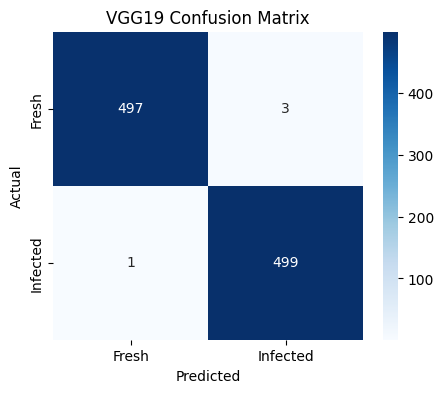


===== Classification Report =====

              precision    recall  f1-score   support

       Fresh   0.997992  0.994000  0.995992       500
    Infected   0.994024  0.998000  0.996008       500

    accuracy                       0.996000      1000
   macro avg   0.996008  0.996000  0.996000      1000
weighted avg   0.996008  0.996000  0.996000      1000


===== Performance Metrics =====
Accuracy : 0.996000
Precision: 0.994024
Recall   : 0.998000
F1-score : 0.996008


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# =========================================
# 🔹 1. PREDICT
# =========================================
y_pred = model_vgg19.predict(test_gen)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)

y_true = test_gen.classes

# =========================================
# 🔹 2. CONFUSION MATRIX
# =========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fresh", "Infected"],
            yticklabels=["Fresh", "Infected"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG19 Confusion Matrix")
plt.show()

# =========================================
# 🔹 3. CLASSIFICATION REPORT
# =========================================
print("\n===== Classification Report =====\n")
print(classification_report(y_true, y_pred, target_names=["Fresh", "Infected"], digits=6))

# =========================================
# 🔹 4. PERFORMANCE METRICS
# =========================================
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)

print("\n===== Performance Metrics =====")
print(f"Accuracy : {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"F1-score : {f1:.6f}")

In [ ]:
# =========================================
# 🔹 VGG19 FEATURE EXTRACTOR
# =========================================
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

for layer in base_model.layers:
    layer.trainable = False

# =========================================
# 🔹 FEATURE EXTRACTION FUNCTION
# =========================================
def extract_features(generator):
    features, labels = [], []

    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat = feature_extractor.predict(x_batch, verbose=0)

        features.append(feat)
        labels.append(y_batch)

    X = np.vstack(features)
    y = np.hstack(labels)

    return X, y

# =========================================
# 🔹 EXTRACT FEATURES
# =========================================
train_gen.shuffle = False  # important

X, y = extract_features(train_gen)
print("Feature shape:", X.shape)

# =========================================
# 🔹 FEATURE SCALING
# =========================================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# =========================================
# 🔹 CLASSIFIERS
# =========================================
classifiers = {
    "SVM": SVC(kernel='rbf', probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "DT": DecisionTreeClassifier(random_state=42),
    "GB": GradientBoostingClassifier(random_state=42)
}

# =========================================
# 🔹 K-FOLD SETUP
# =========================================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = {}

# =========================================
# 🔹 TRAIN + EVALUATE
# =========================================
for name, clf in classifiers.items():
    print(f"\n===== {name} =====")

    accs, precs, recs, f1s = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_val)

        accs.append(accuracy_score(y_val, y_pred))
        precs.append(precision_score(y_val, y_pred, average='macro'))
        recs.append(recall_score(y_val, y_pred, average='macro'))
        f1s.append(f1_score(y_val, y_pred, average='macro'))

        print(f"Fold {fold}: Acc={accs[-1]:.6f}, F1={f1s[-1]:.6f}")

    results[name] = {
        "acc": accs,
        "prec": precs,
        "rec": recs,
        "f1": f1s
    }

# =========================================
# 🔹 CONFIDENCE INTERVAL FUNCTION
# =========================================
def compute_ci(data):
    mean = np.mean(data)
    std = np.std(data)
    n = len(data)

    ci = stats.t.interval(
        0.95,
        df=n-1,
        loc=mean,
        scale=std/np.sqrt(n)
    )

    return mean, ci

# =========================================
# 🔹 FINAL RESULTS (6 DECIMAL + CI)
# =========================================
print("\n===== FINAL RESULTS (95% CI) =====")

for name in classifiers.keys():
    print(f"\n🔹 {name}")

    acc_mean, acc_ci = compute_ci(results[name]["acc"])
    f1_mean, f1_ci   = compute_ci(results[name]["f1"])
    prec_mean, prec_ci = compute_ci(results[name]["prec"])
    rec_mean, rec_ci   = compute_ci(results[name]["rec"])

    print(f"Accuracy : {acc_mean:.6f} ({acc_ci[0]:.6f}, {acc_ci[1]:.6f})")
    print(f"F1-score : {f1_mean:.6f} ({f1_ci[0]:.6f}, {f1_ci[1]:.6f})")
    print(f"Precision: {prec_mean:.6f} ({prec_ci[0]:.6f}, {prec_ci[1]:.6f})")
    print(f"Recall   : {rec_mean:.6f} ({rec_ci[0]:.6f}, {rec_ci[1]:.6f})")

Feature shape: (8000, 512)

===== SVM =====
Fold 1: Acc=0.996250, F1=0.996250
Fold 2: Acc=0.996250, F1=0.996250
Fold 3: Acc=0.998750, F1=0.998750
Fold 4: Acc=1.000000, F1=1.000000
Fold 5: Acc=0.996250, F1=0.996250
Fold 6: Acc=0.997500, F1=0.997500
Fold 7: Acc=1.000000, F1=1.000000
Fold 8: Acc=0.995000, F1=0.995000
Fold 9: Acc=0.998750, F1=0.998750
Fold 10: Acc=0.996250, F1=0.996250

===== KNN =====
Fold 1: Acc=0.995000, F1=0.995000
Fold 2: Acc=0.995000, F1=0.995000
Fold 3: Acc=0.996250, F1=0.996250
Fold 4: Acc=1.000000, F1=1.000000
Fold 5: Acc=1.000000, F1=1.000000
Fold 6: Acc=0.997500, F1=0.997500
Fold 7: Acc=0.996250, F1=0.996250
Fold 8: Acc=0.995000, F1=0.995000
Fold 9: Acc=0.997500, F1=0.997500
Fold 10: Acc=0.996250, F1=0.996250

===== RF =====
Fold 1: Acc=0.992500, F1=0.992500
Fold 2: Acc=0.997500, F1=0.997500
Fold 3: Acc=0.998750, F1=0.998750
Fold 4: Acc=1.000000, F1=1.000000
Fold 5: Acc=1.000000, F1=1.000000
Fold 6: Acc=0.997500, F1=0.997500
Fold 7: Acc=0.997500, F1=0.997500
Fol